Instalar librerías

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

Crear dataset

In [2]:
data = {
    'mensaje': [
        'Excelente taller',
        'Muy buena experiencia',
        'Me encantó la atención',
        'Servicio increíble',
        'Muy recomendado',
        'Mala atención',
        'No me gustó',
        'Experiencia terrible',
        'Muy mal servicio',
        'No volvería'
    ],
    'sentimiento': [
        'positivo',
        'positivo',
        'positivo',
        'positivo',
        'positivo',
        'negativo',
        'negativo',
        'negativo',
        'negativo',
        'negativo'
    ]
}

df = pd.DataFrame(data)

df

,mensaje,sentimiento
0,Excelente taller,positivo
1,Muy buena experiencia,positivo
2,Me encantó la atención,positivo
3,Servicio increíble,positivo
4,Muy recomendado,positivo
5,Mala atención,negativo
6,No me gustó,negativo
7,Experiencia terrible,negativo
8,Muy mal servicio,negativo
9,No volvería,negativo


Dividir datos

In [3]:
X = df['mensaje']
y = df['sentimiento']

vectorizer = CountVectorizer()

X_vectorized = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

Entrenar modelo

In [4]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

Evaluar modelo

In [5]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.0


Probar mensaje nuevo

In [6]:
nuevo_mensaje = ["El taller fue excelente"]

nuevo_vector = vectorizer.transform(nuevo_mensaje)

resultado = model.predict(nuevo_vector)

print("Sentimiento:", resultado[0])

Sentimiento: positivo


Crear gráfica

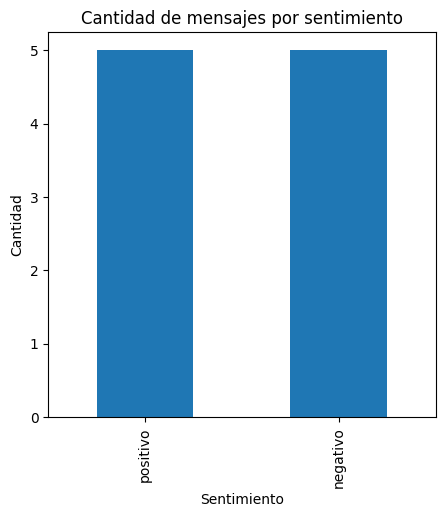

In [7]:
sentimientos = df['sentimiento'].value_counts()

plt.figure(figsize=(5,5))
sentimientos.plot(kind='bar')

plt.title('Cantidad de mensajes por sentimiento')

plt.xlabel('Sentimiento')

plt.ylabel('Cantidad')

plt.show()